In [2]:
# 連接 Google Drive，讓 Colab 可以存取雲端檔案
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os
# 建立 Kaggle 設定資料夾，將 kaggle.json 複製到指定位置
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
# 設定為私人權限，避免憑證外洩
os.system('chmod 600 /root/.kaggle/kaggle.json')

0

In [5]:
# 從 Kaggle 下載肺炎 X 光資料集（約 2GB）
os.system('kaggle datasets download -d paultimothymooney/chest-xray-pneumonia')
# 解壓縮到 /content/chest-xray 資料夾
os.system('unzip chest-xray-pneumonia.zip -d /content/chest-xray')

0

In [6]:
# 載入套件
from fastai import *
from fastai.vision.all import *
from fastai.metrics import error_rate
from pathlib import Path
import os
import pandas as pd
import numpy as np


## 資料載入與探索

從訓練資料夾載入 X 光圖片，自動依資料夾名稱（NORMAL / PNEUMONIA）標記類別。

| 項目 | 數值 |
|------|------|
| 類別數 | 2（NORMAL / PNEUMONIA）|
| 訓練集 | 4,173 張（80%）|
| 驗證集 | 1,043 張（20%）|
| 圖片大小 | 224 × 224（RGB）|

與第一個專題相比，驗證集從 16 張提升至 1,043 張，結果更穩定可靠。

In [7]:
# 設定訓練資料路徑
x = '/content/chest-xray/chest_xray/chest_xray/train'
path = Path(x)
print(path.ls())  # 確認資料夾內容

[Path('/content/chest-xray/chest_xray/chest_xray/train/NORMAL'), Path('/content/chest-xray/chest_xray/chest_xray/train/PNEUMONIA'), Path('/content/chest-xray/chest_xray/chest_xray/train/.DS_Store')]


In [8]:
# 載入資料集並設定資料增強
np.random.seed(40)
data = ImageDataLoaders.from_folder(
    path,                        # 訓練資料路徑
    valid_pct=0.2,               # 抽取 20% 當驗證集
    batch_tfms=aug_transforms(), # 套用資料增強（翻轉、縮放等)
    item_tfms=Resize(128),       # 統一縮放成 128x128
    num_workers=4                # 4個執行緒同時讀取圖片
)

In [9]:
# 確認資料集基本資訊
print('類別：', data.vocab)
print('訓練集：', len(data.train_ds), '張')
print('驗證集：', len(data.valid_ds), '張')

類別： ['NORMAL', 'PNEUMONIA']
訓練集： 4173 張
驗證集： 1043 張


In [10]:
learn = vision_learner(
    data,
    models.resnet50,   # 使用 ResNet50 預訓練模型
    metrics=[accuracy],# 訓練時顯示準確率
    model_dir = Path('/content/drive/MyDrive'),
    path=Path(".")
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 69.3MB/s]


## 模型訓練（ResNet50 遷移學習）

### 訓練策略
分三階段訓練，逐步提升準確率：

| 階段 | 方法 | 輪數 | 最終準確率 |
|------|------|------|-----------|
| 第一階段 | 小學習率快速收斂 | 4輪 | 93.8% |
| 第二階段 | 大學習率衝高準確率 | 20輪 | 97.1% |
| 第三階段 | 解凍全部層，小學習率微調 | 10輪 | 97.7% |

### 最佳學習率（valley）
- 訓練初始：0.001202
- 解凍微調：0.000012（模型已接近最佳狀態，僅需小幅調整）

<div></div>

建議學習率 (valley)：0.001202


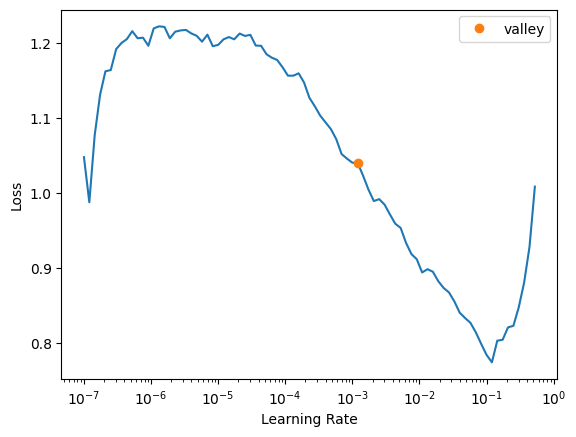

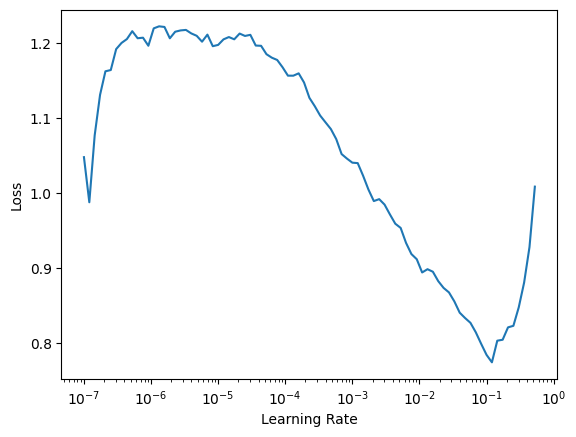

In [11]:
# 尋找最佳學習率
suggest_lr = learn.lr_find()

# 畫出學習率 vs 損失值折線圖
# valley = loss 下降最陡的點，即建議的最佳學習率
learn.recorder.plot_lr_find()
print(f'建議學習率 (valley)：{suggest_lr.valley:.6f}')

In [12]:
# 第一階段：快速收斂，根據 valley 自動設定學習率範圍
lr1 = suggest_lr.valley / 10   # 最小學習率（valley 的十分之一）
lr2 = suggest_lr.valley * 10   # 最大學習率（valley 的十倍）

learn.fit_one_cycle(4, slice(lr1, lr2))

epoch,train_loss,valid_loss,accuracy,time
0,0.498245,0.303914,0.897411,01:37
1,0.316835,0.331011,0.899329,01:38
2,0.228138,0.176257,0.940556,01:38
3,0.187711,0.175536,0.938639,01:36


In [13]:
# 第二階段：用較大學習率進行 20 輪精細訓練
lr = 1e-1  # 固定學習率 0.1
learn.fit_one_cycle(20, slice(lr))

epoch,train_loss,valid_loss,accuracy,time
0,0.195258,0.261885,0.924257,01:38
1,0.289901,0.640344,0.902205,01:35
2,0.362343,0.429208,0.916587,01:36
3,0.313890,0.280403,0.953020,01:35
4,0.456631,0.386458,0.942474,01:37
5,0.475881,0.416540,0.948226,01:35
6,0.478082,0.426352,0.953979,01:38
7,0.329159,0.176374,0.961649,01:35
8,0.237873,0.096117,0.972196,01:35
9,0.180149,0.119872,0.969319,01:33


<div></div>

解凍後建議學習率(valley)：0.000012


epoch,train_loss,valid_loss,accuracy,time
0,0.066796,0.175607,0.972196,01:41
1,0.080714,7.474937,0.942474,01:40
2,0.075515,2.080869,0.967402,01:39
3,0.064375,1.077094,0.965484,01:41
4,0.055341,0.053402,0.982742,01:40
5,0.045921,0.081531,0.978907,01:39
6,0.041840,0.048340,0.978907,01:39
7,0.034234,0.068861,0.975072,01:40
8,0.028277,0.231212,0.968360,01:38
9,0.025857,0.062078,0.976989,01:41


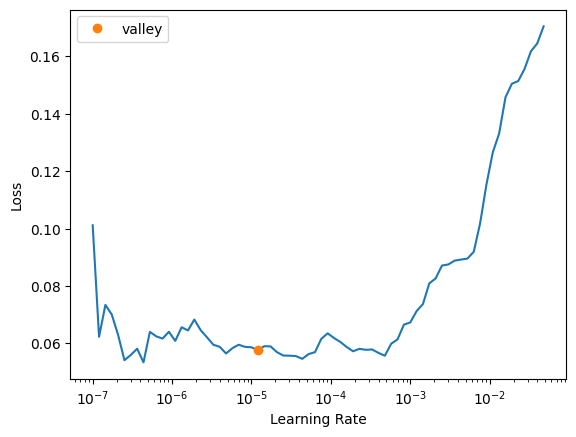

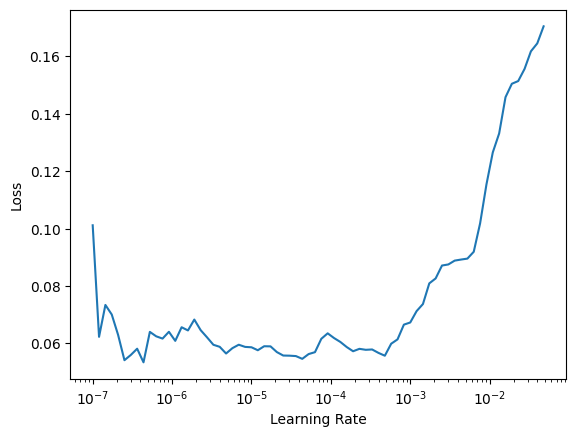

In [14]:
# unfreeze所有層，讓整個模型都可以被訓練（不只最後一層）
learn.unfreeze()

# 重新尋找最佳學習率
suggest_lr2 = learn.lr_find()
learn.recorder.plot_lr_find()
print(f'解凍後建議學習率(valley)：{suggest_lr2.valley:.6f}')

# 小學習率微調整個模型（避免破壞已學到的特徵）
learn.fit_one_cycle(10, slice(1e-4, 1e-3))

<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

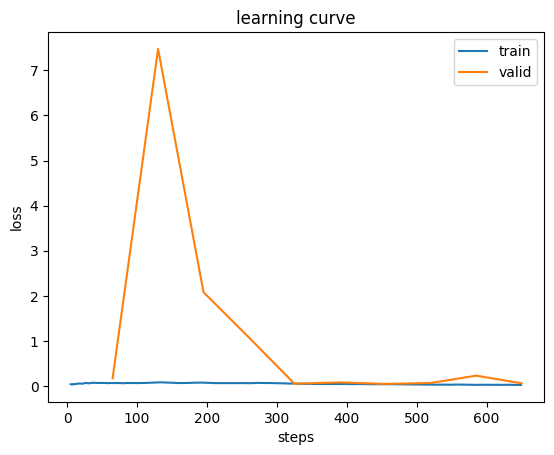

In [16]:
# 畫出訓練集 vs 驗證集的損失值變化
learn.recorder.plot_loss()

## 模型評估與儲存

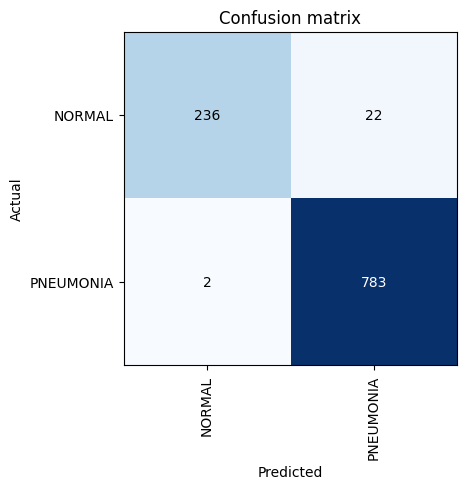

In [17]:
# 對驗證集進行預測分析
interp = ClassificationInterpretation.from_learner(learn)

# 畫出混淆矩陣：顯示模型預測正確與錯誤的分布
interp.plot_confusion_matrix()

<Axes: title={'center': 'Prediction: NORMAL'}>

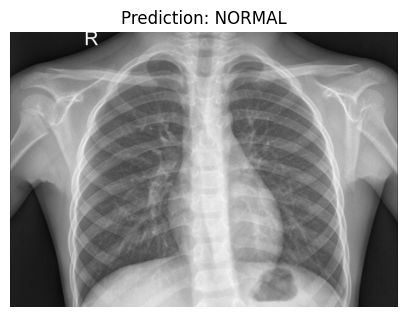

In [19]:
# 對單張 X 光進行預測，驗證模型應用
img = PILImage.create('/content/chest-xray/chest_xray/chest_xray/test/NORMAL/IM-0001-0001.jpeg')
pred, pred_idx, probs = learn.predict(img)
img.show(title=f'Prediction: {pred}')

In [22]:
# 儲存完整模型到 Google Drive
learn.export('/content/drive/MyDrive/pneumonia_model.pkl')

# 儲存模型權重
learn.model_dir = "/content/drive/MyDrive"
learn.save("pneumonia_stage1")

Path('/content/drive/MyDrive/pneumonia_stage1.pth')